<a href="https://colab.research.google.com/github/eteitelbaum/code-satp/blob/main/model-data-size-experiments/perpetrator/exp_perpetrator_cased.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dependecies**

In [ ]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:

import torch


# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Using:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")



GPU is available. Using: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# Assuming your CSV file is named 'conflict_data.csv'
df = pd.read_csv('/content/drive/MyDrive/colab/satp-data/perpetrator.csv')

# Select only the necessary columns
df = df[['incident_summary', 'perpetrator']]

# Drop rows with missing values
df.dropna(inplace=True)

# Assuming your DataFrame is named 'df'
unique_perpetrators = df['perpetrator'].unique()

# Display the unique values
print("Unique values in 'perpetrator':")
print(unique_perpetrators)

Unique values in 'perpetrator':
['Security' 'Maoist' 'Unknown']


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset

# -------------------------------------------------------
# 1. Dataset for Single-Label Multi-Class Classification
# -------------------------------------------------------
class SingleLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        """
        Args:
            texts: List of text strings.
            labels: List of integer class labels (e.g., [0, 1, 2, ...]).
            tokenizer: A Hugging Face AutoTokenizer.
            max_length: Max sequence length for tokenization.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Squeeze batch dimension
        item = {k: v.squeeze() for k, v in encoding.items()}
        # Integer labels for cross-entropy
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

# -------------------------------------------------------
# 2. Custom Metric Function
# -------------------------------------------------------
def compute_metricss(eval_pred, label_names=None):
    """
    Computes accuracy and micro/macro precision/recall/F1 for multi-class classification.
    """
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1).numpy()

    # Accuracy
    acc = accuracy_score(labels, preds)

    # Classification Report (optionally naming classes)
    report = classification_report(
        labels,
        preds,
        target_names=label_names if label_names else None,
        zero_division=0,
        output_dict=True
    )

    if label_names:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, target_names=label_names, zero_division=0))
    else:
        print("\nFull Classification Report:\n",
              classification_report(labels, preds, zero_division=0))
    return {
        "accuracy": acc,
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted": report["weighted avg"]["recall"],
        "f1_weighted": report["weighted avg"]["f1-score"],
    }

# -------------------------------------------------------
# 3. Main Training Function with Train/Val/Test Splits
# -------------------------------------------------------
def train_multiclass_model_3way_split(
    df,
    text_col="incident_summary",
    label_col="perpetrator",
    model_name="bert-base-uncased",
    test_size=0.1,
    val_size=0.1,
    epochs=2,
    batch_size=8
):
    """
    Trains a multi-class classifier with separate train, val, and test sets.

    Args:
        data_path (str): CSV file path. Must contain `text_col` and `label_col`.
        text_col (str): Name of the column containing the text.
        label_col (str): Name of the column containing the class label (string form).
        model_name (str): HF model identifier, e.g. 'bert-base-uncased', 'roberta-base', etc.
        test_size (float): Fraction of entire dataset to hold out for final test set.
        val_size (float): Fraction of entire dataset to hold out for validation set
                          (relative to total, not just leftover).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training and evaluation.

    Returns:
        model: The trained model (same as trainer.model).
        tokenizer: The tokenizer used.
        test_metrics: Evaluation metrics on the test set.
    """

    # 1. Load the data
    # df = pd.read_csv(data_path)

    # 2. Convert label from string to integer IDs
    unique_labels = df[label_col].unique()
    label2id = {label: i for i, label in enumerate(unique_labels)}
    id2label = {v: k for k, v in label2id.items()}

    df["label_id"] = df[label_col].map(label2id)

    # 3. Create initial train+val vs test split
    #    e.g. if test_size=0.1, then 10% of data is test, 90% is train+val
    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=42,
        stratify=df["label_id"]  # optional, if you want stratified splits
    )

    # 4. From the train_val_df, create train vs val split
    #    val_size is fraction of the entire dataset, so the fraction
    #    within train_val_df is val_size / (1 - test_size).
    val_fraction_of_trainval = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_fraction_of_trainval,
        random_state=42,
        stratify=train_val_df["label_id"]
    )

    # 5. Prepare data lists
    train_texts = train_df[text_col].tolist()
    train_labels = train_df["label_id"].tolist()

    val_texts = val_df[text_col].tolist()
    val_labels = val_df["label_id"].tolist()

    test_texts = test_df[text_col].tolist()
    test_labels = test_df["label_id"].tolist()

    # 6. Tokenizer & Model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    num_labels = len(unique_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    model.to(device)


    # 7. Create Dataset objects
    train_dataset = SingleLabelDataset(train_texts, train_labels, tokenizer)
    val_dataset = SingleLabelDataset(val_texts, val_labels, tokenizer)
    test_dataset = SingleLabelDataset(test_texts, test_labels, tokenizer)

    # 8. Training Arguments
    training_args = TrainingArguments(
        output_dir="./model_output",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./logs",
        logging_steps=10,
        report_to="none",
        load_best_model_at_end=False  # set to True if you'd like to restore best checkpoint
    )

    # 9. Create Trainer
    label_names = [id2label[i] for i in range(num_labels)]

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=lambda eval_pred: compute_metricss(eval_pred, label_names=label_names)
    )

    # 10. Train
    trainer.train()

    # 11. Evaluate on the test set
    #     By default, trainer.evaluate() returns a dictionary of metric values
    test_metrics = trainer.evaluate(test_dataset)

    print("\nTest Set Evaluation Results:", test_metrics)

    # Return the final model, tokenizer, and test set metrics
    return trainer.model, tokenizer, test_metrics



In [ ]:


# model, tokenizer, test_metrics = train_multiclass_model_3way_split(
#     df,
#     text_col="incident_summary",
#     label_col="perpetrator",
#     model_name="bert-base-uncased",
#     test_size=0.1,   # 10% of data
#     val_size=0.1,    # 10% of data
#     epochs=2,
#     batch_size=32
# )

# print("Test Accuracy:", test_metrics["eval_accuracy"])


# **Grid loop for Training**

In [ ]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}


In [ ]:
fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]


In [ ]:
import pandas as pd

def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv"):
    """
    1. Iterates over the defined fractions & model list
    2. Samples df_full according to fraction
    3. Trains & evaluates using train_multiclass_model_3way_split
    4. Saves the collected results in a DataFrame
    5. Exports to CSV

    Args:
        df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
        output_csv (str): File path to save the experiment results.
    Returns:
        results_df (pd.DataFrame): Contains experiment results for analysis.
    """
    results_list = []

    for frac in fractions:
        # Sample a fraction of the data
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        # Friendly fraction label if you want
        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            # Model label
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")

            # Train & evaluate
            model, tokenizer, test_metrics = train_multiclass_model_3way_split(
                df_subset,
                text_col="incident_summary",
                label_col="perpetrator",
                model_name=model_name,
                test_size=0.1,   # 10% for test
                val_size=0.1,   # 10% for val
                epochs=2,
                batch_size=32
            )

            # Build a result dict
            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }

            # Merge test_metrics (e.g., accuracy, macro-F1, etc.)
            for k, v in test_metrics.items():
                run_result[k] = v

            # Append to results_list
            results_list.append(run_result)

    # Convert to DataFrame
    results_df = pd.DataFrame(results_list)
    # Save to CSV
    results_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")

    # (Optionally, also save to JSON if desired)
    # results_df.to_json("experiment_results.json", orient="records")

    return results_df


In [ ]:

#
# Example usage:
final_results_df = run_all_experiments_and_save(df, output_csv="experiment_results.csv")

# Now you can inspect final_results_df in Python:
print(final_results_df.head())

# If you want to do more analysis, you can pivot, group, or plot the data.



=== DATA FRACTION: 0.03125 (309 rows) ===
Training model: BERT Base (cased)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,No log,0.793402,0.516129,0.172043,0.333333,0.226950,0.266389,0.516129,0.351407
2,0.888000,0.712389,0.870968,0.585470,0.598214,0.590414,0.846981,0.870968,0.856842



Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.52      1.00      0.68        16
    Security       0.00      0.00      0.00        14
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.52        31
   macro avg       0.17      0.33      0.23        31
weighted avg       0.27      0.52      0.35        31


Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.83      0.94      0.88        16
    Security       0.92      0.86      0.89        14
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.87        31
   macro avg       0.59      0.60      0.59        31
weighted avg       0.85      0.87      0.86        31




Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.80      0.75      0.77        16
    Security       0.75      0.86      0.80        14
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.77        31
   macro avg       0.52      0.54      0.52        31
weighted avg       0.75      0.77      0.76        31


Test Set Evaluation Results: {'eval_loss': 0.7289544939994812, 'eval_accuracy': 0.7741935483870968, 'eval_precision_macro': 0.5166666666666667, 'eval_recall_macro': 0.5357142857142857, 'eval_f1_macro': 0.524731182795699, 'eval_precision_weighted': 0.7516129032258064, 'eval_recall_weighted': 0.7741935483870968, 'eval_f1_weighted': 0.7608740894901145, 'eval_runtime': 0.0875, 'eval_samples_per_second': 354.407, 'eval_steps_per_second': 11.432, 'epoch': 2.0}
Training model: ConfliBERT-scr-cased


...


Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.97      0.96      0.97       519
    Security       0.95      0.94      0.94       427
     Unknown       0.71      0.80      0.76        46

    accuracy                           0.95       992
   macro avg       0.88      0.90      0.89       992
weighted avg       0.95      0.95      0.95       992


Test Set Evaluation Results: {'eval_loss': 0.20041419565677643, 'eval_accuracy': 0.9465725806451613, 'eval_precision_macro': 0.8762146390492157, 'eval_recall_macro': 0.9030636511736055, 'eval_f1_macro': 0.8886854911699631, 'eval_precision_weighted': 0.9480666185459645, 'eval_recall_weighted': 0.9465725806451613, 'eval_f1_weighted': 0.9471785539582573, 'eval_runtime': 2.8874, 'eval_samples_per_second': 343.562, 'eval_steps_per_second': 10.736, 'epoch': 2.0}
Training model: ELECTRA Base


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.150200,0.203015,0.939516,0.857555,0.911499,0.880634,0.943512,0.939516,0.940918
2,0.066000,0.179655,0.944556,0.875016,0.901502,0.887296,0.945999,0.944556,0.945126



Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.97      0.95      0.96       519
    Security       0.94      0.94      0.94       427
     Unknown       0.66      0.85      0.74        46

    accuracy                           0.94       992
   macro avg       0.86      0.91      0.88       992
weighted avg       0.94      0.94      0.94       992


Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.96      0.96      0.96       519
    Security       0.95      0.94      0.94       427
     Unknown       0.71      0.80      0.76        46

    accuracy                           0.94       992
   macro avg       0.88      0.90      0.89       992
weighted avg       0.95      0.94      0.95       992




Full Classification Report:
               precision    recall  f1-score   support

      Maoist       0.98      0.97      0.98       519
    Security       0.96      0.96      0.96       427
     Unknown       0.79      0.80      0.80        46

    accuracy                           0.96       992
   macro avg       0.91      0.91      0.91       992
weighted avg       0.96      0.96      0.96       992


Test Set Evaluation Results: {'eval_loss': 0.14084790647029877, 'eval_accuracy': 0.9596774193548387, 'eval_precision_macro': 0.9073044842141459, 'eval_recall_macro': 0.9123816965951286, 'eval_f1_macro': 0.9098121180430571, 'eval_precision_weighted': 0.9598685483208476, 'eval_recall_weighted': 0.9596774193548387, 'eval_f1_weighted': 0.9597682424755098, 'eval_runtime': 2.1127, 'eval_samples_per_second': 469.531, 'eval_steps_per_second': 14.673, 'epoch': 2.0}

Results saved to experiment_results.csv
   fraction_raw fraction_label  subset_size                      model_raw  \
0       

In [ ]:
import os

# ... (your existing code) ...

# Before saving to JSON and CSV:
os.makedirs("/content/drive/MyDrive/colab/satp-results/perpetrator", exist_ok=True)

# Now save the data:
final_results_df.to_json("/content/drive/MyDrive/colab/satp-results/perpetrator/experiment_results.json", orient="records")
final_results_df.to_csv("/content/drive/MyDrive/colab/satp-results/perpetrator/experiment_results.csv", index=False)

# **Data Analysis**

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/perpetrator/experiment_results.csv')

In [4]:
df.columns

Index(['fraction_raw', 'fraction_label', 'subset_size', 'model_raw',
       'model_label', 'eval_loss', 'eval_accuracy', 'eval_precision_macro',
       'eval_recall_macro', 'eval_f1_macro', 'eval_precision_weighted',
       'eval_recall_weighted', 'eval_f1_weighted', 'eval_runtime',
       'eval_samples_per_second', 'eval_steps_per_second', 'epoch'],
      dtype='object')

### Line Charts of F1 Scores

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_performance(df, x_col, y_col, hue_col, title):
    """
    Plots a line chart with customizable columns.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis
    - y_col: Column name for the y-axis
    - hue_col: Column name for the hue (color grouping)
    - title: Plot title
    """

    plt.figure(figsize=(10, 6))  # Set figure size

    # Create line plot
    ax = sns.lineplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        marker="o",
        palette="colorblind"
    )

    # Clean up y-axis label: Remove 'eval_' prefix if present
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Customize the plot
    ax.legend(title=hue_col.replace("_", " ").title())  # Auto-format legend title
    plt.xlabel(x_col.replace("_", " ").title())  # Auto-format x-axis label
    plt.ylabel(y_label_cleaned)  # Use cleaned y-axis label
    plt.title(title)  # Set custom title
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
    plt.tight_layout()
    plt.show()

#### F1 Weighted

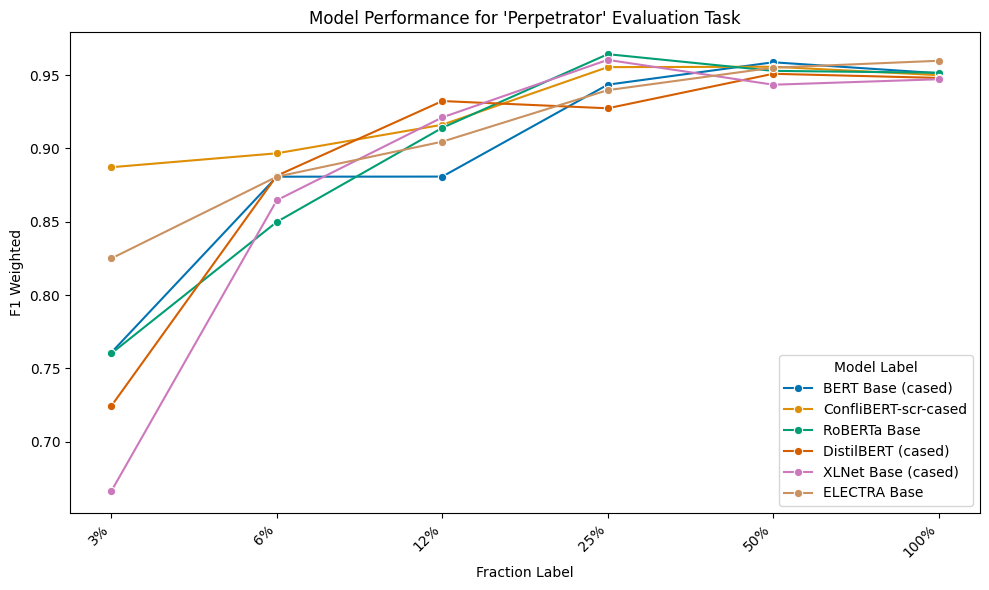

In [44]:
plot_model_performance(
    df=df,
    x_col="fraction_label",
    y_col="eval_f1_weighted",
    hue_col="model_label",
    title="Model Performance for 'Perpetrator' Evaluation Task"
)

### F1 Macro

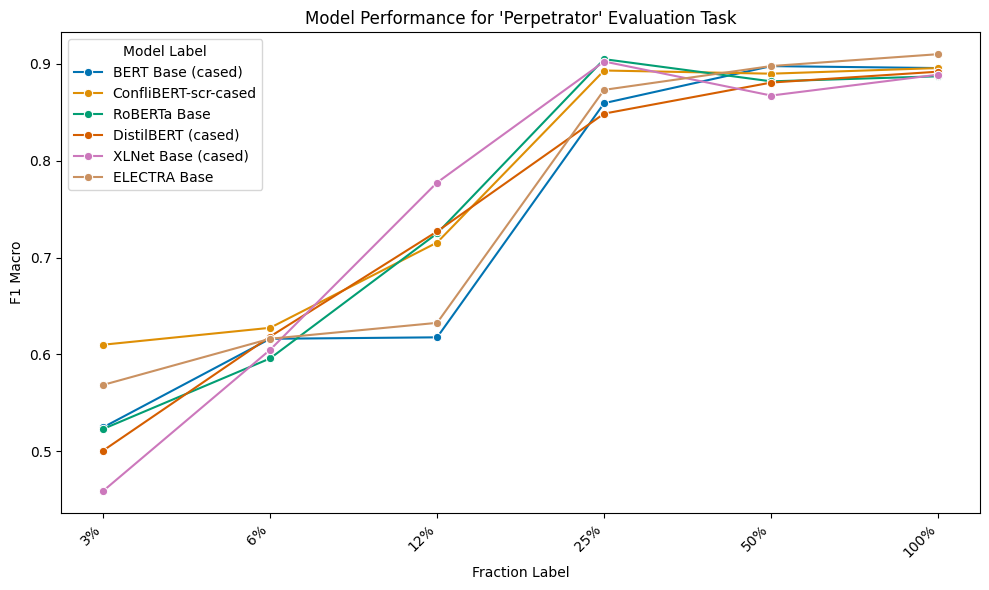

In [45]:
plot_model_performance(
    df=df,
    x_col="fraction_label",
    y_col="eval_f1_macro",
    hue_col="model_label",
    title="Model Performance for 'Perpetrator' Evaluation Task"
)

### Model Performance vs. Speed

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="colorblind"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


#### Weighted F1 vs. Samples per Second

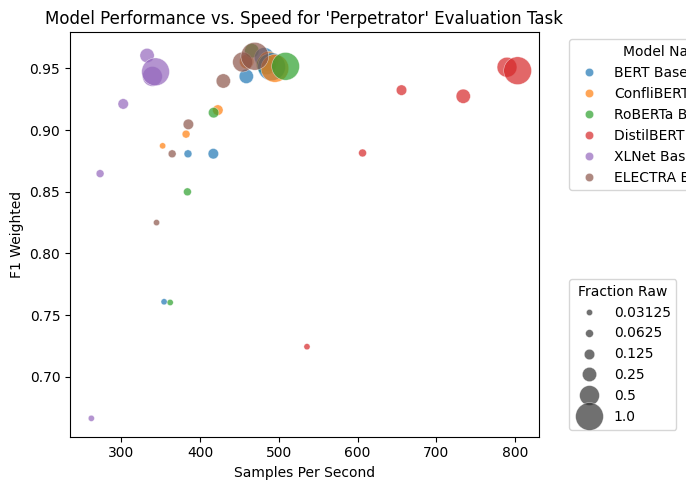

In [54]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_f1_weighted",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Perpetrator' Evaluation Task"
)


#### Weighted F1 vs. Runtime

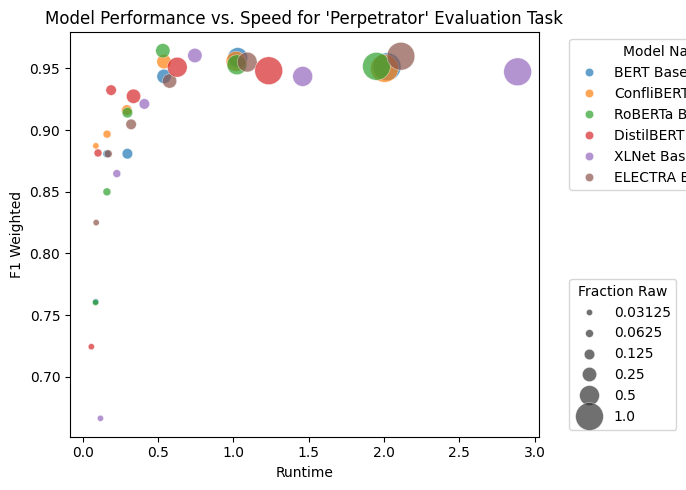

In [55]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_runtime",
    y_col="eval_f1_weighted",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Perpetrator' Evaluation Task"
)


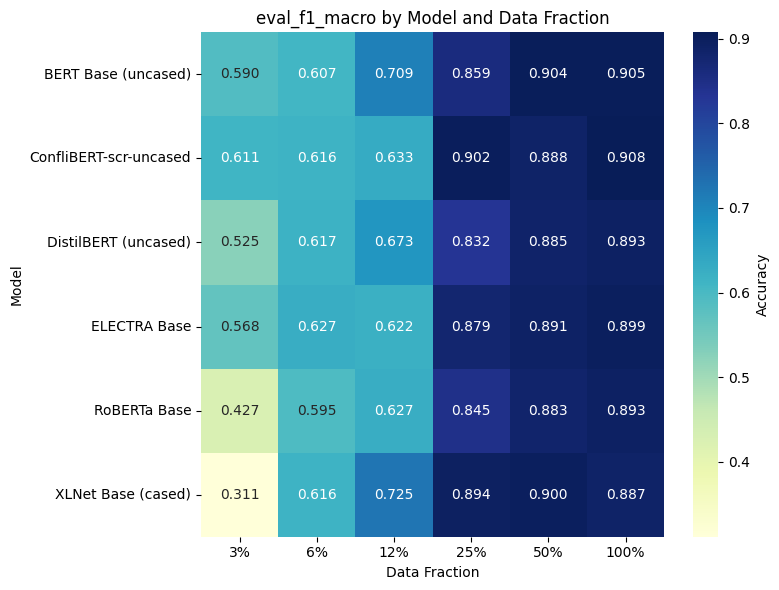

In [ ]:
plot_heatmap(df, "eval_f1_macro")

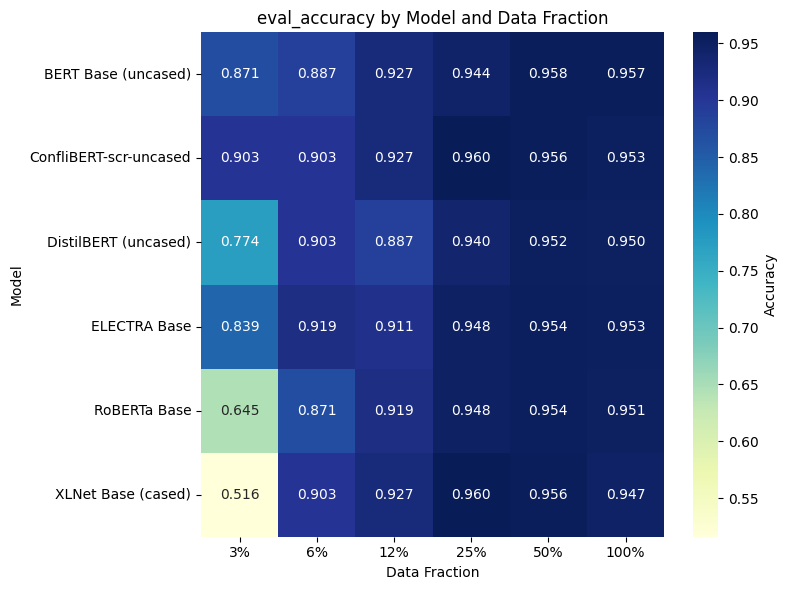

In [ ]:
plot_heatmap(df, "eval_accuracy") # Change plot_heatmap_accuracy to plot_heatmap

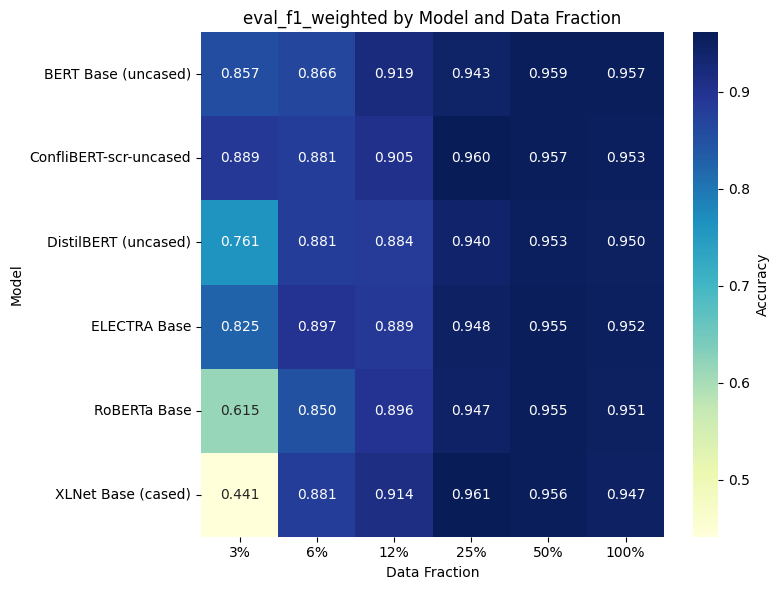

In [ ]:
plot_heatmap(df, "eval_f1_weighted") # Change plot_heatmap_accuracy to plot_heatmap